In [1]:
import pandas as pd
import numpy as np

In [2]:
import tensorflow as tf
import keras

c:\Users\DELL\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from keras.utils import pad_sequences

In [4]:
from keras.datasets import imdb

In [11]:
(x_train, y_train), (x_test, y_test)= imdb.load_data(num_words=10000)

In [12]:
len(x_train[0])

218

In [10]:
y_train[0]

np.int64(1)

In [13]:
from keras.utils import pad_sequences

In [ ]:
x_train= pad_sequences(x_train, padding="post")
x_test= pad_sequences(x_test, padding="post")

In [16]:
len(x_train[0])

2494

In [17]:
from keras.layers import Embedding, Dense, Input, Flatten, SimpleRNN, Dropout, BatchNormalization
from keras.models import Sequential
from keras.regularizers import L2
from keras.callbacks import EarlyStopping

In [25]:
model= Sequential([
    Input(shape=(2494,)),
    Embedding(input_dim=10000, output_dim=2),
    SimpleRNN(64, return_sequences=False),
    Dense(32, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(16, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(8, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(4, activation="relu", kernel_regularizer=L2(0.001)),
    Dense(1, activation="sigmoid")
])

In [26]:
model.compile(
    optimizer="Adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [27]:
callback= EarlyStopping(
    monitor="val_loss",
    min_delta=0.001,
    patience=3,
    mode="auto",
    baseline=None,
    restore_best_weights=True,
    verbose=1
)

In [28]:
history= model.fit(x_train, y_train, epochs=25, validation_data=(x_test, y_test), callbacks=callback, batch_size=512)

Epoch 1/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 46s 913ms/step - accuracy: 0.4996 - loss: 0.7590 - val_accuracy: 0.4999 - val_loss: 0.7449
Epoch 2/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 47s 964ms/step - accuracy: 0.5046 - loss: 0.7348 - val_accuracy: 0.5000 - val_loss: 0.7265
Epoch 3/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 48s 993ms/step - accuracy: 0.4968 - loss: 0.7201 - val_accuracy: 0.5000 - val_loss: 0.7146
Epoch 4/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 47s 970ms/step - accuracy: 0.4994 - loss: 0.7108 - val_accuracy: 0.5000 - val_loss: 0.7072
Epoch 5/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.5000 - loss: 0.7047 - val_accuracy: 0.5000 - val_loss: 0.7024
Epoch 6/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 922ms/step - accuracy: 0.5000 - loss: 0.7008 - val_accuracy: 0.5000 - val_loss: 0.6993
Epoch 7/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 45s 927ms/step - accuracy: 0.4932 - loss: 0.6983 - val_accuracy: 0.5000 - val_loss: 0.6973
Epoch 8/25
49/49 ━━━━━━━━━━━━━━━━━━━━ 168s 3s/step - accuracy: 0.5000 - loss: 0.6966 - val_accuracy:

In [29]:
import matplotlib.pyplot as plt

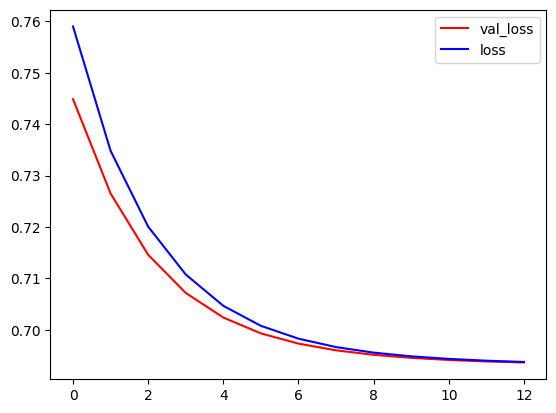

In [30]:
plt.plot(history.history["val_loss"], color="red", label="val_loss")
plt.plot(history.history["loss"], color="blue", label="loss")
plt.legend()

In [31]:
predictions= model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 30s 39ms/step


In [34]:
len(predictions)

25000

In [36]:
predictions= predictions.ravel()
predictions

array([0.50004554, 0.50004554, 0.50004554, ..., 0.50004554, 0.50004554,
       0.50004554], shape=(25000,), dtype=float32)

In [46]:
def results(predictions):
    for i in range(len(predictions)):
        if predictions[i]>=0.5:
            predictions[i]=1
        else:
            predictions[i]=0
    return predictions

In [47]:
predictions= results(predictions)
predictions

array([1., 1., 1., ..., 1., 1., 1.], shape=(25000,), dtype=float32)

In [48]:
0 in predictions

False